<a href="https://colab.research.google.com/github/elean23/2025-webinar-ml-with-python/blob/main/M7_C4_abiertaUGR_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

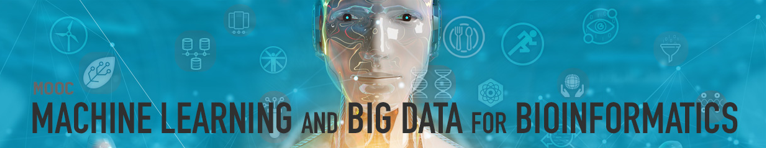
## **Module 7 Big data**
### **7.4 Classification, regression, clustering, and association rules in *Spark***

**By Francisco Javier García Castellano**

*Associate Professor at the Department of Computer Science and Artificial Intelligence (DECSAI), University of Granada.*

**Reminder: Introduction to this NoteBook**.

In this NoteBook, you will be guided step-by-step,through loading a dataset to the descriptive analysis of its contents.

The *Jupyter NoteBook* (Python) is an approach that combines text blocks (like this one) and code blocks or cells. The great advantage of this system is its interactivity because cells can be executed to directly check the results they contain. *Very important*: the order of the instructions is fundamental and so each cell of this NoteBook must be executed sequentially. In any are omitted, the program may throw an error and so if there is any doubt, you will have to start from the beginning again.

First, it is very important to select "*Open in draft mode*" (draft mode) at the top left at the beginning. Otherwise, for security reasons, it will not be allowed to execute any code blocks. When the first of the blocks is executed, the following message will appear: "*Warning: This NoteBook was not created by Google*". Don't worry, you can trust the contents of the *NoteBook* and click on "Run anyway".

Let's start!

Click on the "play" button on the left side of each code cell. Remember that lines beginning with a hashtag (#) are comments and do not affect the execution of the script.

You can also click on each cell and press "*Ctrl+enter*" (*Cmd+enter* on Mac).

Each time you execute a block, you will see the output just below it. The information is usually always the last statement, along with any `print()` commands present in the code.


## **INDEX**


In this NoteBook:
1. We learn about the different supervised learning algorithms available in Apache *Spark*, both for classification and regression.
2. We will also work with different unsupervised learning methods available in *Spark*, such as clustering and association rules.

Contents:
1. Introduction.

2. Classification in Apache *Spark*.

3. Regression in Apache *Spark*.  

4. Clustering in Apache *Spark*.

5. Association rules in Apache *Spark*.



##**1. INTRODUCTION**

We have already seen the methodology used to work with big data using Apache *Spark*.

Now we examine how the different tools already seen in other modules of this course can be used, for example, we will see how to use several regressors or several classifiers in *Spark*. We should point out that the different algorithms we will describe have been programmed to be executed in a distributed, fault-tolerant, and scalable way. In other words, they are designed to be simultaneously executed on many computers, and the more computers in the network, the better they will run. In addition, there will be no problem if one or several of the computers fail.

In this NoteBook we will continue working with *Spark* in Google Colaboratory, so the preliminary work will be the same as previously described, as shown below.

In [ ]:
#First, we install Java and Apache Spark with Hadoop.
!wget -q --show-progress   https://downloads.apache.org/spark/spark-4.1.1/spark-4.1.1-bin-hadoop3.tgz
!tar xf spark-4.1.1-bin-hadoop3.tgz

#Install the Python packages to work with Spark.
!pip install findspark #Install FindSpark
!pip install pyspark   #Install PySpark

#Specify the location of Spark so that PySpark can use it.
import findspark
findspark.init("spark-4.1.1-bin-hadoop3")#SPARK_HOME

#Set the environment variables.
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-4.1.1-bin-hadoop3"


#Create a Spark session to start working.
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("PySpark examples of supervised and unsupervised learning") \
    .config("spark.sql.execution.arrow.enabled", "true") \
    .getOrCreate()


spark-4.1.1-bin-had 100%[===================>] 546.21M  25.1MB/s    in 22s     


##**2. CLASSIFICATION IN APACHE SPARK**

As we saw in the first stages of this course, the data is correctly labeled or classified in supervised learning. Supervised learning algorithms are also called classifiers because, given a set of input variables, they predict which value of the output variable they belong to. Therefore, classifiers contain both the input variables and the output variable.

The first thing we will do is download the data we will work with and then read them into a DataFrame.

In [ ]:
#Download the data sets into Google Colaboratory.
!wget -nv  --no-check-certificate 'https://docs.google.com/uc?export=download&id=1PYzEIdmnfjOnBpPDIFBE9hL1Lkj_OBCk' -O inmune_X.csv
!wget -nv  --no-check-certificate 'https://docs.google.com/uc?export=download&id=1hHQfcvrFa5Jds-9tW_X4sHjKpYKdii9s' -O inmune_Y.csv

#Read the file with the input variables.
dfX = spark.read.csv('inmune_X.csv',inferSchema=True, header=True)
#Read the file with the output variables.
dfY = spark.read.csv('inmune_Y.csv',inferSchema=True, header=True)

#Join the two DataFrames.
df=dfX.join(dfY, dfX._c0 == dfY._c0).drop('_c0')

#Drop the column that indicates the instance number.
dfX=dfX.drop('_c0')
dfY=dfY.drop('_c0')

2026-03-09 12:35:09 URL:https://drive.usercontent.google.com/download?id=1PYzEIdmnfjOnBpPDIFBE9hL1Lkj_OBCk&export=download [314913/314913] -> "inmune_X.csv" [1]
2026-03-09 12:35:10 URL:https://drive.usercontent.google.com/download?id=1hHQfcvrFa5Jds-9tW_X4sHjKpYKdii9s&export=download [3949/3949] -> "inmune_Y.csv" [1]


  Now we prepare the different stages involved in the data preprocessing. In other words, we prepare them to learn models from these data. In addition, we will split them into two sets for use as a training set and a test set.

In [ ]:
#Preprocess the data for use in a supervised learning algorithm.
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import VectorAssembler

#Index the output variable.
indexer = StringIndexer(inputCol="RNASEQ-CLUSTER_CONSENHIER", outputCol="class")

#Join the input variables with VectorAssembler.
assembler = VectorAssembler(inputCols=dfX.columns,outputCol="features")

#Store the stages to be used in a pipeline.
stages=[indexer, assembler]

#Split the data (without preprocessing).
train, test = df.randomSplit([0.7, 0.3], seed = 2020)

Different classifiers have already been implemented in Apache *Spark*. We will distinguish those used for binary classification (i.e., the output variable has only two states) from those used for multi-class classification (i.e., those in which the output variable has more than two states).

<table>
<tr>
<th><p>Problem Type</p>
</th><th><p> Implemented algorithms in Spark</p>
</th></tr>

<tr><td><p>Binary classsification</p>
</td><td><p>
<a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#binomial-logistic-regression">Binomial Logistic Regression</a><br/>
<a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#linear-support-vector-machine"> Linear Support Vector Machines</a><br/>
<a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#decision-tree-classifier">Decision Tree</a><br/>
<a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#random-forest-classifier">Random Forest</a><br/>
<a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#gradient-boosted-tree-classifier">Gradient-boosted Tree</a><br/>
<a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#multilayer-perceptron-classifier">Multilayer Perceptron</a><br/>
<a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#naive-bayes">Naïve Bayes</a></p>
</td></tr>

<tr><td><p>Multiclass clasification</p>
</td><td><p><a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#multinomial-logistic-regression">Multinomial Logistic Regression</a> <br/>
<a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#decision-tree-classifier">Decision Tree</a><br/>
<a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#random-forest-classifier">Random Forest</a><br/>
<a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#gradient-boosted-tree-classifier">Gradient-boosted tree</a><br/>
<a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#multilayer-perceptron-classifier">Multilayer Perceptron</a><br/>
<a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#naive-bayes">Naïve Bayes</a><br />
<a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#one-vs-rest-classifier-aka-one-vs-all">One-vs-Rest  (One-vs-all)</a></p>
</td></tr>

</table>

As shown in the table, all the classifiers that allow us to work with multiclass problems, also allow us to work with binary problems. This makes sense, given that if an algorithm can discriminate between 4 or 10 output variable values, it should also be able to distinguish between 2.

There is a binary and a multiclass version for logistic regression while support vector machines only allow binary classification.

The one-vs-all meta-classifier appears in the multiple classification section but not in the binary classification section. This is not a classifier in itself because it requires a base classifier. However, this scheme allows us to use binary classifiers in multiclass problems by building a base classifier for each value of the output variable. This distinguishes the i-th value of the output variable from the remaining variables.

Let’s now look at an example of a classifier:

In [ ]:
from pyspark.ml.classification import LinearSVC

#Define the model: SVM.
svm = LinearSVC(featuresCol = 'features', labelCol = 'class',maxIter=10)

#Build a pipeline with the preprocesing and the SVM.
pipeline=Pipeline().setStages(stages+[svm] )

#Fit the model to the training dataset.
modelSVM = pipeline.fit(train)

#Make predictions with the learned model (preprocessing + SVM).
predictions = modelSVM.transform(test)

#Next, display the goodness of the model.
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator(labelCol="class", metricName="accuracy")
print('Accuracy:', evaluator.evaluate(predictions))

Accuracy: 0.7764705882352941



In the previous example we used the [Linear Support Vector Machine](https://spark.apache.org/docs/latest/ml-classification-regression.html#linear-support-vector-machine) (or SVM) and learnt a binary classifier from the previously generated data.


Three parameters appeared in the logistic regression and they also appear in this example, as described below:



* **`featuresCol`**: This indicates which variable of the *DataFrame* contains all the input variables joined with `VectorAssembler`. In our examples, we used the default value called **`features`**.
* **`labelCol`**: Indicates which variable of the *DataFrame* is the output variable. In our examples, it is usually called `class`, but if no value is given its deafult is **`label`**.
* **`maxIter`**: This indicates the maximum number of iterations performed by the algorithm. Many machine learning algorithms are optimized by iterative processes. Therefore, it is the maximum number of iterations required to run the optimization algorithm; too small a value may worsen the results and too large a value may take too long or overfit the data.

More information on the parameters used can be found in [logistic regression](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.LogisticRegression.html), or in [support vector machines](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.LinearSVC.html) in the application programming interface (*API*).


We will now use a decision tree.

In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier

#Define the decision tree and its parameters.
dt = DecisionTreeClassifier(featuresCol = 'features', labelCol = 'class')

#Build a pipeline with the preprocesing and the tree.
pipeline=Pipeline().setStages(stages+[dt] )

#Fit the model to the training dataset.
modelDT = pipeline.fit(train)

#Make predictions with the learned model (preprocessing + tree).
predictions = modelDT.transform(test)

#Display the accuracy of the model
print('Accuracy:', evaluator.evaluate(predictions))


Accuracy: 0.7058823529411765


[Decision tree](https://spark.apache.org/docs/latest/ml-classification-regression.html#decision-tree-classifier) is an interpretable model which we can imagine as a compacted set of  **"*IF .... THEN ...*"** type rules.

Among the [decision tree parameters](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.DecisionTreeClassifier.html), it is especially worth highlighting:

*  **`maxDepth`**: The maximum depth of the tree for the number of nodes, which by default, is 5.
* **`minInstancesPerNode`**: The minimum number of instances required to keep branching the tree, which by default, is 1.
* **`minInfoGain`**: The minimum threshold of the splitting criterion required for further branching, which by default, is 0.
* **`maxBins`**: The number of intervals used to discretize continuous variables, which by default, is 32.
* **`impurity`**: Criterion used to split the tree, which can take one of two values: `entropy` or `gini`, the latter being the default value.

The parameters `maxDepth`, `minInstancesPerNode`, and `minInfoGain` are used to limit the tree growth, a practice referred to as pre-pruning.



In [ ]:
from pyspark.ml.classification import RandomForestClassifier

#Define a random forest (RF).
rf = RandomForestClassifier(featuresCol = 'features', labelCol = 'class', numTrees=10)

#Build a pipeline with the preprocessing and the random forest.
pipeline=Pipeline().setStages(stages+[rf] )

#Fit the model to the train dataset and test it.
predictions = pipeline.fit(train).transform(test)

#Display the accuracy of the model.
print('Accuracy:', evaluator.evaluate(predictions))


Accuracy: 0.8705882352941177


 The next classifier we will see is [**Multilayer Perceptron**](https://spark.apache.org/docs/latest/ml-classification-regression.html#multilayer-perceptron-classifier) , which is quite a popular type of **artificial neural network** (ANN). To use it, we must specify the architecture of the neural network, that is, the number of layers and the number of artificial neurons per layer.

The input layer has as many neurons as input variables and the output layer must have as many neurons as the number of values of the output variable. In addition, we can indicate as many hidden layers as we want.

To specify the architecture of the neural network we will use a list, where each element represents a layer and a number indicates how many neurons are used in each layer. The `layers` argument is used to specify the architecture of the multilayer perceptron.

In [ ]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

#Specify the architecture of the artificial neural network (ANN).
layers = [len(dfX.columns) , int(len(dfX.columns)/2), int(len(dfX.columns)/4), 2]

#Define the neural network.
ann = MultilayerPerceptronClassifier(featuresCol = 'features', labelCol = 'class',
                                     maxIter=100, layers=layers)

#Build a pipeline with the preprocessing and the ANN.
pipeline=Pipeline().setStages(stages+[ann] )

#Fit the model to the training dataset.
modelANN = pipeline.fit(train)

#Make predictions with the learned model (preprocessing + ANN).
predictions = modelANN.transform(test)

#Display the goodness of the model.
print('Accuracy:', evaluator.evaluate(predictions))



Accuracy: 0.8352941176470589


In Capsule 3 of Module 5 (*Advanced methods in classification*) when we looked at *Ensemble* models, that is, sets of classifiers that function as one, we distinguished two approaches: *Bagging* and *Boosting*. In that Module, the **random forest** classifier was presented as an example of *Bagging*. However, we did not examine any examples of *Boosting*.
In the following example, we will see a  *Boosting ensemble*, namely the [**Gradient Boosted Tree** (GBT)](https://spark.apache.org/docs/latest/ml-classification-regression.html#gradient-boosted-tree-classifier).  Instead of learning many decision trees at once like *random forest*, it builds decision trees stepwise, seeking to improve the results of the immediately preceding tree. In Apache *Spark*, GBT is implemented in the `GBTClassifier` class, while the number of iterations also indicates the number of decision trees generated.

In [ ]:
from pyspark.ml.classification import GBTClassifier

# Train a Gradient Boosted Tree (GBT) model.
gbt = GBTClassifier(featuresCol = 'features', labelCol = 'class', maxIter=100)

#Build a pipeline with the preprocessing and the GBT.
pipeline=Pipeline().setStages(stages+[gbt] )

#Fit the model to the training dataset.
modelGBT = pipeline.fit(train)

#Make predictions with the learned model (preprocessing + GBT).
predicctions = modelGBT.transform(test)

#Display the accuracy of the model.
print('Accuracy:', evaluator.evaluate(predictions))



Accuracy: 0.8352941176470589


##**3. REGRESSION IN APACHE *SPARK***

So far, we have worked with classification problems (i.e. supervised learning problems where the output variable is discrete) but now we will see how to work with **Regression** where the output variable is continuous. Learning regressors or classifiers is conceptually the same, although the models and how the results are evaluated will be different.


To begin with, we will download the **HOMA** dataset and save it in a *DataFrame* to start working with it.

In [ ]:
#Download the data set into Google Colaboratory.
!wget -nv --no-check-certificate 'https://docs.google.com/uc?export=download&id=1GO2NBxYw54K6HkN-YgXbNadrLo5O6-0u' -O HOMA.csv

#Read the dataset with all the variables.
dfR = spark.read.csv('HOMA.csv',inferSchema=True, header=True)
dfR.show(5)


2026-03-09 12:37:20 URL:https://drive.usercontent.google.com/download?id=1GO2NBxYw54K6HkN-YgXbNadrLo5O6-0u&export=download [29228/29228] -> "HOMA.csv" [1]
+---+----+-------+-------+-----+----+--------+---------+---------+-----+----+----------+----------+---------+---------+-----+
|Sex| Age| Tanner| Height|  BMI|  WC| TAGmgDL| HDLCmgDL| LDLCmgDL|  SBP| DBP| Sedentary|     Light| Moderate| Vigorous| HOMA|
+---+----+-------+-------+-----+----+--------+---------+---------+-----+----+----------+----------+---------+---------+-----+
|  1| 9.5|    0.0|   1.55|11.34|60.0|    55.0|     51.0|     93.0| 97.0|60.0|411.089286|321.580357|22.133929| 3.982143| 1.98|
|  1| 8.0|    0.0|   1.15| 12.4|46.3|    51.0|     70.0|     59.0| 90.0|55.0|435.607143| 316.97619|48.059524| 14.27381| 0.87|
|  0|10.5|    0.0|   1.42|12.99|67.5|    65.0|     60.0|     96.0| 96.0|54.0|483.904762|337.785714|33.309524| 7.988095| 1.46|
|  0| 8.1|    0.0|   1.27|13.43|53.1|    41.0|     78.0|    100.0|108.0|46.0|429.297619| 

Now let's prepare the dataset to work with it in Apache *Spark*. The first thing we will do is change the name of the output variable to `label`, the default value used by *Spark*.

Next, we will index the discrete variable `Sex`. After that, we must join the input variables with `VectorAssembler`.

Thus, we will leave the preprocessing steps ready to add to the pipeline along with the regressor. Finally, we will split the input data into training and test sets.

In [ ]:
#Change the name of the output variable.
dfR=dfR.withColumnRenamed(" HOMA","label")

#Index the categorial variables.
indexer = StringIndexer(inputCol="Sex", outputCol="SexI")

#Join the input variables with VectorAssembler.
inputVars=dfR.columns
inputVars.append('SexI')
inputVars.remove('Sex')
inputVars.remove('label')
assembler = VectorAssembler(inputCols=inputVars, outputCol="features")

#store the preprocessing stages to be used in a pipeline.
stagesR=[indexer, assembler]

#Split the data (without preprocessing).
trainR, testR = dfR.randomSplit([0.7, 0.3], seed = 2020)
print ("Train ", trainR.count(),' instances.')
print ("Test  ", testR.count(),' instances.')

Train  216  instances.
Test   76  instances.


In the following example we will use [linear regression](https://spark.apache.org/docs/latest/ml-classification-regression.html#linear-regression), which we already looked at in detail in Module 4(*Supervised learning: regression techniques*), to make our predictions about the data set.

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

#Define the linear regressor.
lr = LinearRegression()

#Build a pipeline with the preprocessing and the regressor.
pipeline=Pipeline().setStages(stagesR+[lr] )

#Fit the model to the training dataset.
regressor = pipeline.fit(trainR)

#Make predictions with the learned model (preprocessing + linear regressor).
predictions = regressor.transform(testR)

#Display the goodness of the model.
evaluatorR = RegressionEvaluator()
print('rmse:', evaluatorR.evaluate(predictions))
print('r2:', evaluatorR.evaluate(predictions, {evaluatorR.metricName: "r2"}))

rmse: 0.7907446870395332
r2: 0.4543573119593476


We can also use decision trees in regression problems, using the same parameters same as in classification problems.



In [ ]:
from pyspark.ml.regression import DecisionTreeRegressor

#Define a decision tree regressor.
dtR = DecisionTreeRegressor()

#Build a pipeline with the preprocessing and the regressor.
pipeline=Pipeline().setStages(stagesR+[dtR] )

#Fit the model to the train dataset and test it.
predictions = pipeline.fit(trainR).transform(testR)
print('rmse:', evaluatorR.evaluate(predictions))
print('r2:', evaluatorR.evaluate(predictions, {evaluatorR.metricName: "r2"}))

rmse: 0.9945250479132998
r2: 0.136887858629134


As we have already seen, we can use decision trees as regressors; as in supervised learning, we can use a set of decision trees in an *ensemble*. To do this we can follow a *bagging* strategy to generate different trees using different training subsets. This allows us to use sets of regressors in a [*random forest*](https://spark.apache.org/docs/latest/ml-classification-regression.html#random-forest-regression) by using the [`RandomForestRegressor`](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.RandomForestRegressor.html#pyspark.ml.regression.RandomForestRegressor) class in Apache *Spark*.

In the following example, we will see a *random forest* regressor, whose most interesting parameter is `numTrees` which indicates the number of trees to use:

In [ ]:
from pyspark.ml.regression import RandomForestRegressor

#Define a random forest for regression.
rfR = RandomForestRegressor(numTrees=10)

#Build a pipeline with the preprocessing and the regressor.
pipeline=Pipeline().setStages(stagesR+[rfR] )

#Fit the model to the training dataset and test it.
predictions = pipeline.fit(trainR).transform(testR)
print('rmse:', evaluatorR.evaluate(predictions))
print('r2:', evaluatorR.evaluate(predictions, {evaluatorR.metricName: "r2"}))

rmse: 0.776095522956415
r2: 0.47438696038944494


The examples we have looked at here are only a subset of the regressors implemented in Apache *Spark* (shown in the following table).

<table>
<tr>
<th><p> Regression methods implemented in Apache <i>Spark</i></p>
</th></tr>

<tr><td><p>
<a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#linear-regression">Linear Regression</a></p><br/></td></tr>

<tr><td><p><a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#generalized-linear-regression">Generalized Linear Regression</a></p><br/></td></tr>
<tr><td><p><a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#decision-tree-regression"> Decision Tree</a></p><br/></td></tr>
<tr><td><p><a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#random-forest-regression">Random Forest</a></p><br/></td></tr>

<tr><td><p><a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#gradient-boosted-tree-regression">Gradient Boosted Trees</a></p><br/></td></tr>

<tr><td><p><a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#survival-regression">Survival Regression</a></p><br/></td></tr>

<tr><td><p><a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#isotonic-regression">Isotonic Regression </a></p><br/></td></tr>

<tr><td><p><a href="https://spark.apache.org/docs/latest/ml-classification-regression.html#factorization-machines-regressor">Factorization Machines</a></p><br/></td></tr>
</table>

##**4. CLUSTERING IN APACHE *SPARK***

So far, we have worked in *Spark* with supervised learning algorithms; in other words, we have input variables and an output variable that we wanted to predict.

In this section we will work with unsupervised learning. As we previously saw, clustering allows us to discover groups of variables in the data; these groups (or clusters) are a set of instances that are similar to each other.

To work with the different clustering algorithms in *Spark*, we will first load the 1,500 gene expression matrix that we obtained in Module 2 (Bioinformatic analysis of an omics problem).

In [ ]:
#Download the data set into Google Colaboratory.
!wget -nv --no-check-certificate 'https://docs.google.com/uc?export=download&id=1rQd3EHPQvDSVsjwMZG3oM7khRCR_EPwi' -O clustering.csv

#Read the dataset with all the variables.
dfC = spark.read.csv('clustering.csv', inferSchema=True, header=True)
dfC.show(5)

2026-03-09 12:37:33 URL:https://drive.usercontent.google.com/download?id=1rQd3EHPQvDSVsjwMZG3oM7khRCR_EPwi&export=download [12254970/12254970] -> "clustering.csv" [1]
+------+-----------------+-----------------+------------------+-----------------+------------------+-----------------+-----------------+-----------------+-----------------+-----------------+-------------------+------------------+-----------------+-----------------+-----------------+-----------------+------------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+-----------------+-----------------+-----------------+-----------------+------------------+-----------------+-----------------+-----------------+----------------+-----------------+-----------------+-----------------+-----------------+--------

Now we will apply the [*K*-means](https://spark.apache.org/docs/latest/ml-clustering.html#k-means) algorithm to the data. This is one of the simplest and most popular clustering algorithms used in unsupervised learning. Let's first look at some of its most relevant [parameters](https://spark.apache.org/docs/latest/api/python/pyspark.ml.html#pyspark.ml.clustering.KMeans):

* **`k`**: Indicates the number of centroids to use, in other words, the number of clusters to be detected.
* **`maxIter`**: Indicates the maximum number of iterations that will be performed by the algorithm.
* **`distanceMeasure`**: Specifies the distance algorithm to use, which can either have a `cosine` or `euclidean` (default) value.





In [ ]:
from pyspark.ml.clustering import KMeans

#Join the input variables with VectorAssembler.
inputVars=dfC.columns
inputVars.remove('_c0')
assembler = VectorAssembler(inputCols=inputVars, outputCol="features")

# Define a K-means model for clustering, using 2 clusters.
kmeans = KMeans(k=2)

#Build a pipeline with the preprocessing and K-means.
pipeline=Pipeline().setStages([assembler,kmeans] )

#Fit the model to the data.
modelKMeans = pipeline.fit(dfC)


The evaluation of unsupervised learning models is difficult because of the nature of the clustering problem: the clusters are not known in advance and it is not easy to separate the good clusters from the bad ones. To hellp us with this problem we can calculate the *Silhouette index* which, as we saw in Capsule 2 of Module 6 (*Clustering*), is an estimate of the cohesion of an instance with its cluster and of separation from the other clusters. It always falls between [-1, 1], and the higher the number, the better. To calculate this index in *Spark*, we must use the `ClusteringEvaluator` class, which reminds us of the evaluators used in regression and classification.

In [ ]:
from pyspark.ml.evaluation import ClusteringEvaluator

#Make predictions with the learned model (preprocessing + K-means).
predictions = modelKMeans.transform(dfC)

#Evaluate the clustering algorithm using the Silhouette index.
evaluator = ClusteringEvaluator()
silhouette = evaluator.evaluate(predictions)
print("The silhouette index is = " + str(silhouette)+" (using k=2)")

The silhouette index is = 0.12238176898838295 (using k=2)




Another model is [bisecting-K-means](https://spark.apache.org/docs/latest/ml-clustering.html#bisecting-k-means) (a hierarchical variant of K-means); at each step, this algorithm splits each cluster in two using K-means.


In [ ]:
from pyspark.ml.clustering import BisectingKMeans

# Define a bisecting K-means model for clustering, using 2 clusters.
bkmeans = BisectingKMeans().setK(2)

#Build a pipeline with the preprocessing and bisecting-K-means.
pipeline=Pipeline().setStages([assembler,bkmeans] )

#Fit the model to the data.
modelBKMeans = pipeline.fit(dfC)

#Make predictions with the learned model (preprocessing + bisecting-K-means).
predictionsB = modelBKMeans.transform(dfC)

#Evaluate the clustering algorithm using the Silhouette index.
silhouette = evaluator.evaluate(predictionsB)
print("The silhouette index is = " + str(silhouette)+" (using k=2)")

The silhouette index is = 0.17492723894069465 (using k=2)


However, you should be aware that *Spark* contains other clustering methods, as shown in the following table.




<table>
<tr>
<th><p> Clustering methods implemented in Spark</p>
</th></tr>

<tr><td><p>
<a href="https://spark.apache.org/docs/latest/ml-clustering.html#k-means">K-Means </a></p><br/></td></tr>
<tr><td><p><a href="https://spark.apache.org/docs/latest/ml-clustering.html#latent-dirichlet-allocation-lda">Latent Dirichlet Allocation</a></p><br/></td></tr>
<tr><td><p><a href="https://spark.apache.org/docs/latest/ml-clustering.html#bisecting-k-means">Bisecting K-Means</a></p><br/></td></tr>
<tr><td><p><a href="https://spark.apache.org/docs/latest/ml-clustering.html#gaussian-mixture-model-gmm"> Gaussian Mixture Model</a></p><br/></td></tr>
<tr><td><p><a href="https://spark.apache.org/docs/latest/ml-clustering.html#power-iteration-clustering-pic">Power Iteration Clustering</a></p><br/></td></tr>


</table>

##**5. ASSOCIATION RULES IN APACHE *SPARK***

Association rules are another unsupervised learning tool that will allow us to discover relationships between variables in large datasets. Apache Spark contains the [FP-growth](https://spark.apache.org/docs/latest/ml-frequent-pattern-mining.html#fp-growth) algorithm that we have already seen.   

The problem here is in the data preprocessing because the transactional data format accepted by Spark's FP-Growth algorithm must be numeric and unique (i.e. it does not allow repeated items), and all the itemsets must be in an `array`. In addition, the `get_dummies()` method of `pandas` is not available in *Spark*, so we will have to create a column for each state of each variable.

In [ ]:
from pyspark.sql import functions as F

#Download the data set into Google Colaboratory.
!wget  -nv --no-check-certificate 'https://docs.google.com/uc?export=download&id=1j7bPKMcMo1jHU-zERXo1lmUtbKw7AHlI' -O datos_entrada_reglas.csv
#Read the dataset with all the variables.
dfAR = spark.read.csv('datos_entrada_reglas.csv', inferSchema=True, header=True)
dfAR.show(5)

#Add a new column for each possible state of each variable.
newVars=[]
counter=1
vars=dfAR.columns
#Iterate through the variables.
for var in vars:
  #Iterate through each state of each variable.
  for state in dfAR.select(var).distinct().collect():
    if state[var] != '_': #Ignore null values.
      #If this status is present, we will add a unique identifier, if it is not then 0.
      dfAR = dfAR.withColumn(var+"="+state[var],
        F.when(dfAR[var] == state[var], counter).otherwise(0))
      #Increase the identifying number of each state.
      counter=counter+1
      #Save the generated columns in a list.
      newVars.append(var+"="+state[var])
print("\nData with columns for each state of each variable:")
dfAR.select(newVars).show(5)

#Let's show what each numerical identifier means.
print("\nIdentifiers used for each state of each variable:")
for i in range(len(newVars)):
  print(i+1,"=",newVars[i])

#Join the variables with the array function, because VectorAssembler returns a
#Vector and FPGrowth requires the itemsets to be in an array.
dataAR = dfAR.withColumn('itemsWithZeros', F.array(newVars))
dataAR=dataAR.withColumn("items", F.array_remove("itemsWithZeros", 0))

print("\nData processed for FPGrowth:")
dataAR = dataAR.withColumn("id", F.monotonically_increasing_id())
dataAR.select("id","items").show(5,False)

2026-03-09 12:38:03 URL:https://drive.usercontent.google.com/download?id=1j7bPKMcMo1jHU-zERXo1lmUtbKw7AHlI&export=download [22613/22613] -> "datos_entrada_reglas.csv" [1]
+--------------------+------------+-------------------------+--------------------+----------+----------------+
|    MUTATIONSUBTYPES|UV_signature|RNASEQ_CLUSTER_CONSENHIER|    MethTypes_201408|MIRCluster|LYMPHOCYTE_SCORE|
+--------------------+------------+-------------------------+--------------------+----------+----------------+
|BRAF_Hotspot_Mutants|UV_signature|                  keratin|         normal_like|MIR_type_3|               2|
| RAS_Hotspot_Mutants|UV_signature|                  keratin|CpG_island_methyl...|MIR_type_2|               4|
|BRAF_Hotspot_Mutants|UV_signature|                  keratin|         normal_like|MIR_type_1|               5|
| RAS_Hotspot_Mutants|UV_signature|                  keratin|     hypo_methylated|MIR_type_2|               2|
|           Triple_WT|      not_UV|                 

Implementation of FP-growth in *Spark* requires the following parameters:

* **`minSupport`**: The minimum support required for an *itemset* to be identified as frequent.
* **`minConfidence`**: The minimum confidence required to generate an association rule. The parameter will not affect the extraction of frequent *itemsets*, but will determine the minimum confidence to generate association rules from frequent itemsets.

Once we have learned the model, we can use the `freqItemsets` method to obtain the frequent *itemsets*, or we can use the `associationRules` method to obtain the association rules.

In [ ]:
from pyspark.ml.fpm import FPGrowth

#Use FP-growth algorithm.
fpGrowth = FPGrowth(itemsCol="items", minSupport=0.25, minConfidence=0.2)

#Fit the model to the data.
modeloFPgrowth = fpGrowth.fit(dataAR)

#Display the frequent itemsets.
modeloFPgrowth.freqItemsets.show()

#Show the association rules obtained.
modeloFPgrowth.associationRules.show()


+------+----+
| items|freq|
+------+----+
|   [5]| 265|
|   [8]| 168|
|[8, 5]| 142|
|   [4]| 150|
|[4, 5]| 136|
|   [7]| 102|
|  [11]|  93|
|   [1]|  92|
|[1, 5]|  86|
|  [19]|  91|
|  [13]|  85|
|  [14]|  85|
|  [10]|  84|
+------+----+

+----------+----------+-------------------+------------------+-------------------+
|antecedent|consequent|         confidence|              lift|            support|
+----------+----------+-------------------+------------------+-------------------+
|       [8]|       [5]| 0.8452380952380952|1.0621293800539082| 0.4264264264264264|
|       [4]|       [5]| 0.9066666666666666| 1.139320754716981| 0.4084084084084084|
|       [5]|       [8]| 0.5358490566037736|1.0621293800539084| 0.4264264264264264|
|       [5]|       [4]| 0.5132075471698113| 1.139320754716981| 0.4084084084084084|
|       [5]|       [1]|0.32452830188679244|1.1746513535684988|0.25825825825825827|
|       [1]|       [5]| 0.9347826086956522|1.1746513535684988|0.25825825825825827|
+----------+--

The *a priori* algorithm is not implemented in Apache *Spark*. However, as we have seen, the *FP-Growth* algorithm is implemented.
<table>
<tr>
<th><p> Association Rules Algorithms in Apache <i>Spark</i></p>
</th></tr>

<tr><td><p><a href="https://spark.apache.org/docs/latest/ml-frequent-pattern-mining.html#fp-growth">FP-Growth </a></p><br/></td></tr>
<tr><td><p><a href="https://spark.apache.org/docs/latest/ml-frequent-pattern-mining.html#prefixspan"> PrefixSpan </a></p><br/></td></tr>

</table>

## **BIBLIOGRAPHICAL REFERENCES**

* The Apache Software Foundation."Classification and regression". (2020). [Accessed 23 June 2020]. Available from: https://spark.apache.org/docs/latest/ml-classification-regression.html#classification-and-regression

* The Apache Software Foundation."Clustering". (2020). [Accessed 23 June 2020]. Available from: https://spark.apache.org/docs/latest/ml-clustering.html#clustering

* The Apache Software Foundation."Frequent Pattern Mining". (2020). [Accessed 23 June 2020]. Available from: https://spark.apache.org/docs/latest/ml-frequent-pattern-mining.html#frequent-pattern-mining

<div class="alert alert-block alert-success">

MOOC Machine Learning and Big Data for Bioinformatics (6th edition)  
http://abierta.ugr.es     
    
![CC](https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc-nd.png)
</div>    